# Importation des bibliothèques

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation du jeu de données

In [3]:
def read_data():
    data_score_credit = pd.read_csv('../data/cs-training.csv')
    return data_score_credit

In [5]:
data_score_credit = read_data()
data_score_credit.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Renommage des colonnes pour qu'elles soient plus compréhensible.

In [7]:
data_score_credit.rename(columns={'SeriousDlqin2yrs': 'target',
                         'RevolvingUtilizationOfUnsecuredLines': 'taux_utilisation_credit',
                         'age': 'age',
                         'NumberOfTime30-59DaysPastDueNotWorse': 'nbr_30-59_jours_retard',
                         'DebtRatio': 'ratio_endettement',
                         'MonthlyIncome':'Revenus_mensuel', 
                         'NumberOfOpenCreditLinesAndLoans':'nbr_lignes_credit_ouvertes',
                         'NumberOfTimes90DaysLate': 'nbr_90_jours_retard',
                         'NumberRealEstateLoansOrLines': 'nbr_prets_immobilier',
                         'NumberOfTime60-89DaysPastDueNotWorse':'nbr_60-89_jours_retard',
                        'NumberOfDependents' : 'nbr_person_foyer'
                        

                         }, inplace=True)

data_score_credit.head()

,Unnamed: 0,target,taux_utilisation_credit,age,nbr_30-59_jours_retard,ratio_endettement,Revenus_mensuel,nbr_lignes_credit_ouvertes,nbr_90_jours_retard,nbr_prets_immobilier,nbr_60-89_jours_retard,nbr_person_foyer
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Visualisation des méta données

In [16]:
data_score_credit.isnull().sum()

Unnamed: 0                        0
target                            0
taux_utilisation_credit           0
age                               0
nbr_30-59_jours_retard            0
ratio_endettement                 0
Revenus_mensuel               29731
nbr_lignes_credit_ouvertes        0
nbr_90_jours_retard               0
nbr_prets_immobilier              0
nbr_60-89_jours_retard            0
nbr_person_foyer               3924
dtype: int64

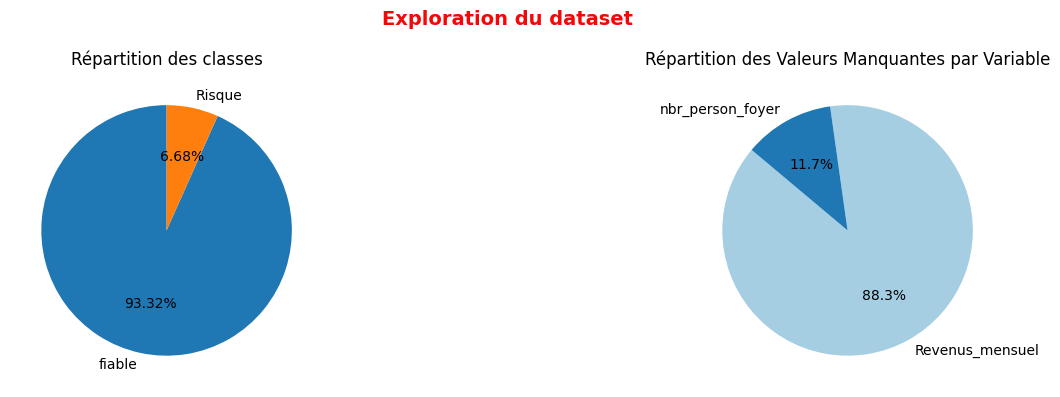

In [ ]:
target = data_score_credit['target'].value_counts()
valeur_manquante = data_score_credit.isnull().sum()
seul_valeur_manquante = valeur_manquante[valeur_manquante > 0]
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Exploration du dataset", color="#f40707", fontsize=14, fontweight='bold')

# Pie fraude
labels_pie = ['fiable', 'Risque']

axes[0].pie([target[0], target[1]], labels=labels_pie,
            autopct='%1.2f%%', startangle=90)
axes[0].set_title("Répartition des classes")


axes[1].pie(
        seul_valeur_manquante, 
        labels=seul_valeur_manquante.index, 
        autopct='%1.1f%%', # Affiche le pourcentage sur le cercle
        startangle=140, 
        colors=plt.cm.Paired.colors # Utilise une palette de couleurs variées
    )
axes[1].set_title("Répartition des Valeurs Manquantes par Variable")

plt.tight_layout()
plt.show()

target
0    0.93316
1    0.06684
Name: proportion, dtype: float64
target
0    6.168855
1    4.367282
Name: taux_utilisation_credit, dtype: float64


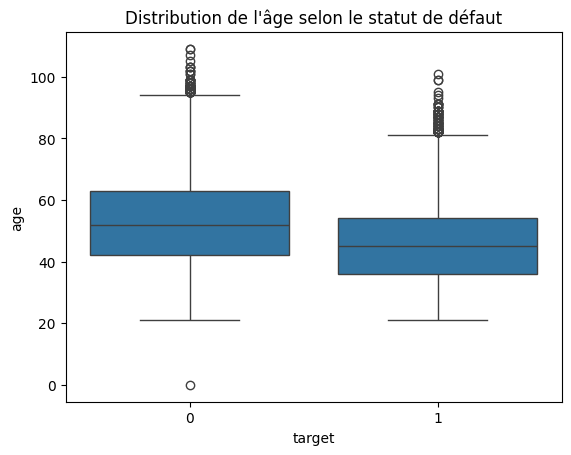

In [13]:
# 1. Vérifier le déséquilibre de la cible
print(data_score_credit['target'].value_counts(normalize=True))

# 2. Comparer la moyenne du taux d'utilisation du crédit selon la cible
print(data_score_credit.groupby('target')['taux_utilisation_credit'].mean())


sns.boxplot(x='target', y='age', data=data_score_credit)
plt.title("Distribution de l'âge selon le statut de défaut")
plt.show()